# Paper Reproduction Notebook

This notebook reproduces all figures and tables from the paper using precomputed artifacts.
No API key or external access is required — it reads only precomputed CSV files.

**To reproduce:** Run all cells in order. See `REPRODUCING_RESULTS.md` for full details.

In [72]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import re
from pathlib import Path

## Setup

Paths to precomputed artifacts and metric computation functions.

In [73]:
# # Path to ablation results
results_dir = Path("../precomputed/gpt_4o_mini/ablation_results")

# --- File config ---
csv_files = sorted([
    f for f in results_dir.glob("nested_cv_llm__anonymised*.csv")
    if "chronological" not in f.name.lower()
])

# --- Labels of interest ---
target_labels_map = {
    "F0_5": "Optimise $F_{0.5}$",
    "F1": "Optimise $F_{1}$",
    "F2": "Optimise $F_{2}$",
    "PRECISION": "Optimise Precision",
}

# --- Compute F-score ---
def f_beta_score(tp, fp, fn, beta=0.5):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    beta_sq = beta ** 2
    return (1 + beta_sq) * (precision * recall) / (beta_sq * precision + recall)

def compute_pooled_metrics(df):
    grouped = df.groupby("Repeat")
    total_tp = sum(group["TP"].sum() for _, group in grouped)
    total_fp = sum(group["FP"].sum() for _, group in grouped)
    total_fn = sum(group["FN"].sum() for _, group in grouped)
    return {
        "Precision": round(total_tp / (total_tp + total_fp), 4) if total_tp + total_fp > 0 else 0.0,
        "Recall": round(total_tp / (total_tp + total_fn), 4) if total_tp + total_fn > 0 else 0.0,
        "F0.5": round(f_beta_score(total_tp, total_fp, total_fn, beta=0.5), 4),
        "F1": round(f_beta_score(total_tp, total_fp, total_fn, beta=1.0), 4),
        "F2": round(f_beta_score(total_tp, total_fp, total_fn, beta=2.0), 4),
    }

def compute_avg_metrics(metrics_list):
    precisions, recalls, f05s = [], [], []
    for m in metrics_list:
        tp, fp, fn = m["TP"], m["FP"], m["FN"]
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f05 = (1.25 * prec * rec / (0.25 * prec + rec)) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f05s.append(f05)
    return {
        "Precision": round(np.mean(precisions), 4),
        "Recall": round(np.mean(recalls), 4),
        "F0.5": round(np.mean(f05s), 4)
    }

## Optimisation Target Comparison

Table comparing F0.5, F1, F2, and Precision optimisation targets.

In [74]:
metric_table = []
for file in csv_files:
    stem = file.stem
    if not (
        "similarity_hamming_0_15" in stem and
        "sortbyf0_5" in stem and
        "__expert" not in stem and
        "__expert_only" not in stem and
        "cluster" not in stem
    ):
        continue  # skip files that don’t exactly match

    df = pd.read_csv(file)
    if not all(col in df.columns for col in ["Repeat", "TP", "FP", "FN"]):
        continue

    match = re.search(r"optimise([A-Z0-9_]+)_sortby", stem)
    if not match:
        continue

    opt_key = match.group(1)
    if opt_key in target_labels_map:
        label = target_labels_map[opt_key]

        # Create list of per-repeat metrics
        grouped = df.groupby("Repeat")
        repeat_metrics = []
        for _, g in grouped:
            repeat_metrics.append({
                "TP": g["TP"].sum(),
                "FP": g["FP"].sum(),
                "FN": g["FN"].sum(),
            })

        metrics = compute_avg_metrics(repeat_metrics)
        metric_table.append({"Optimisation Target": label, **metrics})


## Main Results: RRF vs Baselines

Comparison of RRF, elastic net, and vanilla LLM prompting (zero-shot and few-shot).

In [75]:
# --- Load vanilla results with precomputed metrics ---
vanilla_dir = Path("../precomputed/gpt_4o_mini/vanilla")

vanilla_files = {
    "Zero-shot GPT-4o": "vanilla_zero_shot_gpt_4o_mini_anonymised_rep_1.csv",
    "Zero-shot o3": "vanilla_zero_shot_o3_anonymised_rep_1.csv",
    "Zero-shot o3-mini": "vanilla_zero_shot_o3_mini_anonymised_rep_1.csv",
    "Few-shot GPT-4o": "vanilla_few_shot_gpt_4o_mini_anonymised_rep_1.csv",
    "Few-shot o3": "vanilla_few_shot_o3_anonymised_rep_1.csv",
    "Few-shot o3-mini": "vanilla_few_shot_o3_mini_anonymised_rep_1.csv",
}

vanilla_metrics = {}
for label, fname in vanilla_files.items():
    df = pd.read_csv(vanilla_dir / fname)
    if all(c in df.columns for c in ["Prec", "Rec", "F0.5"]):
        vanilla_metrics[label] = {
            "Precision": round(df["Prec"].iloc[3], 3),
            "Recall": round(df["Rec"].iloc[3], 3),
            "F0.5": round(df["F0.5"].iloc[3], 3),
        }

# --- RRF: compute per-repeat metrics for mean ± SD ---
rrf_file = Path("../precomputed/gpt_4o_mini/ablation_results/nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv")
rrf_df = pd.read_csv(rrf_file)

rrf_repeat_metrics = {"Precision": [], "Recall": [], "F0.5": []}
for _, g in rrf_df.groupby("Repeat"):
    tp, fp, fn = g["TP"].sum(), g["FP"].sum(), g["FN"].sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f05 = (1.25 * p * r / (0.25 * p + r)) if (p + r) > 0 else 0.0
    rrf_repeat_metrics["Precision"].append(p)
    rrf_repeat_metrics["Recall"].append(r)
    rrf_repeat_metrics["F0.5"].append(f05)

rrf_row = {
    "Precision": np.mean(rrf_repeat_metrics["Precision"]),
    "Recall": np.mean(rrf_repeat_metrics["Recall"]),
    "F0.5": np.mean(rrf_repeat_metrics["F0.5"]),
    "Precision_SD": np.std(rrf_repeat_metrics["Precision"], ddof=1),
    "Recall_SD": np.std(rrf_repeat_metrics["Recall"], ddof=1),
    "F0.5_SD": np.std(rrf_repeat_metrics["F0.5"], ddof=1),
}

# --- LogReg: compute per-repeat metrics for mean ± SD ---
logreg_bench_path = Path("../precomputed/gpt_4o_mini/benchmark_results/benchmark_gpt_4o_mini.csv")
logreg_bench = pd.read_csv(logreg_bench_path)
en_rows = logreg_bench[logreg_bench["Model"] == "ElasticNet LogReg"]

lr_repeat_metrics = {"Precision": [], "Recall": [], "F0.5": []}
for _, g in en_rows.groupby("Repeat"):
    lr_repeat_metrics["Precision"].append(g["Test Prec"].mean())
    lr_repeat_metrics["Recall"].append(g["Test Rec"].mean())
    lr_repeat_metrics["F0.5"].append(g["Test F0.5"].mean())

lr_row = {
    "Precision": np.mean(lr_repeat_metrics["Precision"]),
    "Recall": np.mean(lr_repeat_metrics["Recall"]),
    "F0.5": np.mean(lr_repeat_metrics["F0.5"]),
    "Precision_SD": np.std(lr_repeat_metrics["Precision"], ddof=1),
    "Recall_SD": np.std(lr_repeat_metrics["Recall"], ddof=1),
    "F0.5_SD": np.std(lr_repeat_metrics["F0.5"], ddof=1),
}

# --- Build combined table ---
custom_order = [
    ("RRF", "LLM + Ensemble", rrf_row, True),
    ("LogReg (EN)", "Learned Weights", lr_row, True),
    ("o3", "Few Shot", vanilla_metrics.get("Few-shot o3", {}), False),
    ("GPT-4o-mini", "Zero Shot", vanilla_metrics.get("Zero-shot GPT-4o", {}), False),
    ("o3-mini", "Zero Shot", vanilla_metrics.get("Zero-shot o3-mini", {}), False),
    ("GPT-4o-mini", "Few Shot", vanilla_metrics.get("Few-shot GPT-4o", {}), False),
    ("o3", "Zero Shot", vanilla_metrics.get("Zero-shot o3", {}), False),
    ("o3-mini", "Few Shot", vanilla_metrics.get("Few-shot o3-mini", {}), False),
]

# Sort by F0.5 descending
custom_order.sort(key=lambda x: x[2].get("F0.5", 0), reverse=True)

# Find max values for bolding
all_prec = [r[2]["Precision"] for r in custom_order]
all_rec = [r[2]["Recall"] for r in custom_order]
all_f05 = [r[2]["F0.5"] for r in custom_order]
max_prec, max_rec, max_f05 = max(all_prec), max(all_rec), max(all_f05)

# Format table
rows = []
for model, approach, metrics, has_sd in custom_order:
    row = {"Model": model, "Approach": approach}
    for col in ["Precision", "Recall", "F0.5"]:
        val = metrics[col]
        is_max = (col == "Precision" and val == max_prec) or \
                 (col == "Recall" and val == max_rec) or \
                 (col == "F0.5" and val == max_f05)
        if has_sd:
            sd = metrics[f"{col}_SD"]
            text = f"{val:.3f} ± {sd:.3f}"
        else:
            text = f"{val:.3f}"
        if is_max:
            text = f"**{text}**"
        row[col] = text
    rows.append(row)

styled_table = pd.DataFrame(rows)

print("\n📊 Final Table (Markdown-style for LaTeX):\n")
print(styled_table.to_markdown(index=False))

# Also print raw values for easy LaTeX copy-paste
print("\n\nRaw values:")
print(f"RRF:    Prec={rrf_row['Precision']:.3f}±{rrf_row['Precision_SD']:.3f}, "
      f"Rec={rrf_row['Recall']:.3f}±{rrf_row['Recall_SD']:.3f}, "
      f"F0.5={rrf_row['F0.5']:.3f}±{rrf_row['F0.5_SD']:.3f}")
print(f"LogReg: Prec={lr_row['Precision']:.3f}±{lr_row['Precision_SD']:.3f}, "
      f"Rec={lr_row['Recall']:.3f}±{lr_row['Recall_SD']:.3f}, "
      f"F0.5={lr_row['F0.5']:.3f}±{lr_row['F0.5_SD']:.3f}")


📊 Final Table (Markdown-style for LaTeX):

| Model       | Approach        | Precision         | Recall        | F0.5              |
|:------------|:----------------|:------------------|:--------------|:------------------|
| RRF         | LLM + Ensemble  | **0.123 ± 0.010** | 0.100 ± 0.007 | **0.118 ± 0.008** |
| o3          | Few Shot        | 0.077             | 0.196         | 0.088             |
| GPT-4o-mini | Zero Shot       | 0.079             | 0.139         | 0.086             |
| o3-mini     | Zero Shot       | 0.070             | 0.177         | 0.080             |
| LogReg (EN) | Learned Weights | 0.089 ± 0.022     | 0.077 ± 0.018 | 0.080 ± 0.016     |
| GPT-4o-mini | Few Shot        | 0.065             | **0.316**     | 0.077             |
| o3          | Zero Shot       | 0.083             | 0.036         | 0.066             |
| o3-mini     | Few Shot        | 0.038             | 0.286         | 0.047             |


Raw values:
RRF:    Prec=0.123±0.010, Rec=0.100±0.007,

In [76]:
# Helper functions
def extract_metrics_from_file(file):
    df = pd.read_csv(file)
    grouped = df.groupby("Repeat")
    metrics = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})
    for name, group in grouped:
        metrics[name]["TP"] += group["TP"].sum()
        metrics[name]["FP"] += group["FP"].sum()
        metrics[name]["FN"] += group["FN"].sum()
    return list(metrics.values())

# --- Question source data (for combined figure panel a) ---
file_llm = f"{results_dir}/nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv"
file_llm_exp = f"{results_dir}/nested_cv_llm_expert__anonymisedsimilarity_hamming_0_01_optimiseF0_5_sortbyf0_5.csv"
file_exp = f"{results_dir}/nested_cv_expert_only__anonymisedsimilarity_cosine-cluster_0_85_optimiseF0_5_sortbyf0_5_exp1.csv"

llm_metrics = compute_avg_metrics(extract_metrics_from_file(file_llm))
llm_exp_metrics = compute_avg_metrics(extract_metrics_from_file(file_llm_exp))
exp_metrics = compute_avg_metrics(extract_metrics_from_file(file_exp))

## Question-Generating Model Comparison

Comparison across four question-generating LLMs: GPT-4o-mini, Gemini 2.5 Pro, Claude Sonnet 4.5, and GPT-5.2.
Each model's questions were scored by GPT-4o-mini on the same test set.

In [77]:
# === New Ablation: Question-Generating Model Comparison ===
# Each model's questions were answered by gpt-4o-mini on the same test set.
# We use each model's best hamming threshold (selected via nested CV).

model_ablation_configs = {
    "GPT-4o-mini": "../precomputed/gpt_4o_mini/ablation_results/nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv",
    "Gemini\n2.5 Pro": "../precomputed/gemini_2_5_pro/ablation_results/nested_cv_llm__anonymisedsimilarity_hamming_0_10_optimiseF0_5_sortbyf0_5.csv",
    "Claude\nSonnet 4.5": "../precomputed/claude_sonnet_4_5/ablation_results/nested_cv_llm__anonymisedsimilarity_hamming_0_30_optimiseF0_5_sortbyf0_5.csv",
    "GPT-5.2": "../precomputed/gpt_5_2/ablation_results/nested_cv_llm__anonymisedsimilarity_hamming_0_20_optimiseF0_5_sortbyf0_5.csv",
}

model_ablation_scores = {}
for label, path in model_ablation_configs.items():
    metrics = extract_metrics_from_file(path)
    avg = compute_avg_metrics(metrics)
    model_ablation_scores[label] = avg

# Also load LogReg benchmark results for each model
benchmark_configs = {
    "GPT-4o-mini": None,  # No benchmark file for precomputed; skip
    "Gemini\n2.5 Pro": "../precomputed/gemini_2_5_pro/benchmark_results/benchmark_gemini_2_5_pro.csv",
    "Claude\nSonnet 4.5": "../precomputed/claude_sonnet_4_5/benchmark_results/benchmark_claude_sonnet_4_5.csv",
    "GPT-5.2": "../precomputed/gpt_5_2/benchmark_results/benchmark_gpt_5_2.csv",
}

logreg_scores = {}
for label, path in benchmark_configs.items():
    if path is None:
        continue
    bdf = pd.read_csv(path)
    en_rows = bdf[bdf["Model"] == "ElasticNet LogReg"]
    if not en_rows.empty:
        logreg_scores[label] = en_rows["Test F0.5"].mean()

# Print summary table
print("\n📊 Question-Generating Model Comparison (RRF, best threshold per model):\n")
print(f"{'Model':<25} {'Prec':>8} {'Rec':>8} {'F0.5':>8} {'LogReg F0.5':>12}")
print("-" * 60)
for label, scores in model_ablation_scores.items():
    clean_label = label.replace('\n', ' ')
    lr = logreg_scores.get(label, None)
    lr_str = f"{lr:.4f}" if lr else "—"
    print(f"{clean_label:<25} {scores['Precision']:8.4f} {scores['Recall']:8.4f} {scores['F0.5']:8.4f} {lr_str:>12}")


📊 Question-Generating Model Comparison (RRF, best threshold per model):

Model                         Prec      Rec     F0.5  LogReg F0.5
------------------------------------------------------------
GPT-4o-mini                 0.1235   0.1000   0.1179            —
Gemini 2.5 Pro              0.1129   0.0892   0.1072       0.0613
Claude Sonnet 4.5           0.1282   0.0376   0.0833       0.0606
GPT-5.2                     0.0654   0.0611   0.0644       0.0415


In [78]:
# === Question-Generating Model Comparison: data gathering ===

# --- Gather all data ---
rrf_scores = {}
for label, path in model_ablation_configs.items():
    metrics = extract_metrics_from_file(path)
    avg = compute_avg_metrics(metrics)
    rrf_scores[label] = avg["F0.5"]

logreg_paths = {
    "GPT-4o-mini": "../precomputed/gpt_4o_mini/benchmark_results/benchmark_gpt_4o_mini.csv",
    "Gemini\n2.5 Pro": "../precomputed/gemini_2_5_pro/benchmark_results/benchmark_gemini_2_5_pro.csv",
    "Claude\nSonnet 4.5": "../precomputed/claude_sonnet_4_5/benchmark_results/benchmark_claude_sonnet_4_5.csv",
    "GPT-5.2": "../precomputed/gpt_5_2/benchmark_results/benchmark_gpt_5_2.csv",
}

lr_scores = {}
for label, path in logreg_paths.items():
    try:
        bdf = pd.read_csv(path)
        en = bdf[bdf["Model"] == "ElasticNet LogReg"]
        lr_scores[label] = en["Test F0.5"].mean()
    except:
        lr_scores[label] = 0.0

# Order by RRF score descending
model_order = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)

print("Data summary:")
print(f"{'Model':<25} {'RRF F0.5':>10} {'LogReg F0.5':>12} {'Winner':>8}")
print("-" * 58)
for m in model_order:
    clean = m.replace('\n', ' ')
    rrf = rrf_scores[m]
    lr = lr_scores.get(m, 0)
    winner = "RRF" if rrf >= lr else "LogReg"
    print(f"{clean:<25} {rrf:10.3f} {lr:12.3f} {winner:>8}")

Data summary:
Model                       RRF F0.5  LogReg F0.5   Winner
----------------------------------------------------------
GPT-4o-mini                    0.118        0.080      RRF
Gemini 2.5 Pro                 0.107        0.061      RRF
Claude Sonnet 4.5              0.083        0.061      RRF
GPT-5.2                        0.064        0.041      RRF


## Combined Ablation Figure

Five-panel figure covering: question source, question-generating model, similarity metric, Hamming threshold, and evaluation strategy.

/var/folders/6v/3j_zk93j4456xdt1t6708r380000gn/T/ipykernel_64759/2972120006.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


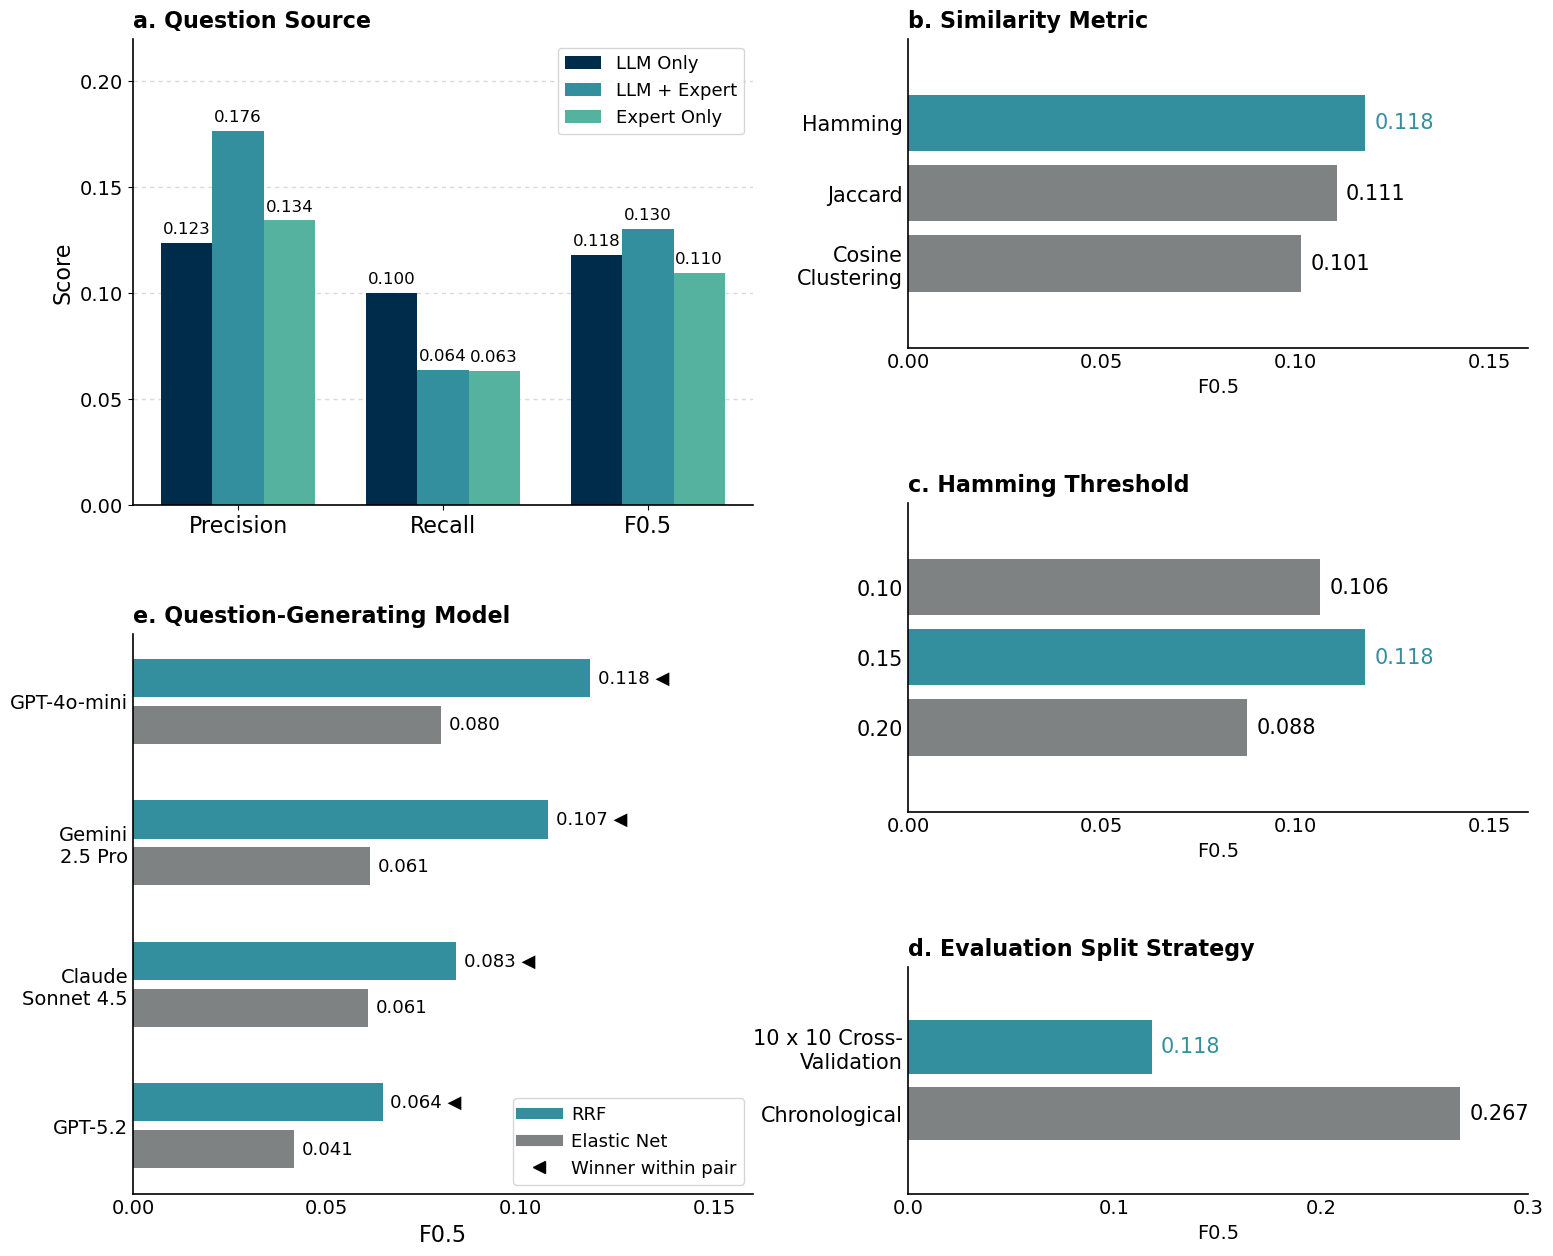

In [79]:
# =====================================================================
# Combined Figure: all main panels in one layout
# Top-left (a): Question Source (LLM Only / LLM+Expert / Expert Only)
# Bottom-left (e): Question-Generating Model (RRF vs Elastic Net)
# Right column (b-d): Ablation panels
# =====================================================================
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# --- Load ablation data for panels b-d ---
ablation_dir = Path("../precomputed/gpt_4o_mini/ablation_results")

ablation_files = {
    # Similarity metric (panel b)
    "LLM-Only\nhamming, sim=0.15; optimise=f0.5; sortby=f0.5":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv",
    "LLM-Only\njaccard, sim=0.9; optimise=f0.5; sortby=f0.5":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_jaccard_0_90_optimiseF0_5_sortbyf0_5.csv",
    "LLM-Only\ncosine-cluster, sim=0.85; optimise=f0.5; sortby=f0.5":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_cosine-cluster_0_85_optimiseF0_5_sortbyf0_5.csv",
    # Hamming threshold (panel c)
    "LLM-Only\nhamming, sim=0.1; optimise=f0.5; sortby=f0.5":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_10_optimiseF0_5_sortbyf0_5.csv",
    "LLM-Only\nhamming, sim=0.2; optimise=f0.5; sortby=f0.5":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_20_optimiseF0_5_sortbyf0_5.csv",
    # Rank-by (not used directly as a panel but needed for pooled_means)
    "LLM-Only\nhamming, sim=0.15; optimise=f0.5; sortby=precision":
        ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyprecision.csv",
}

pooled_means = {}
for label, fpath in ablation_files.items():
    metrics = extract_metrics_from_file(str(fpath))
    avg = compute_avg_metrics(metrics)
    pooled_means[label] = avg["F0.5"]

# CV vs chronological (panel d)
file_cv = ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv"
file_chron = ablation_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5_chronological.csv"
score_cv = compute_avg_metrics(extract_metrics_from_file(str(file_cv)))["F0.5"]
score_chr = compute_avg_metrics(extract_metrics_from_file(str(file_chron)))["F0.5"]

# --- Build figure ---
fig = plt.figure(figsize=(18, 15))

# Layout: 2 cols; left split into 2 rows, right split into 3 rows
gs_outer = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.25)

# Left column: top (a) and bottom (e)
gs_left = gs_outer[0].subgridspec(2, 1, height_ratios=[1, 1.2], hspace=0.25)

# Right column: 3 ablation panels (b, c, d)
gs_right = gs_outer[1].subgridspec(3, 1, height_ratios=[3, 3, 2.2], hspace=0.55)

# === Shared style settings ===
highlight_color = "#338f9e"
default_color = "#7f8283"
bar_colors_3 = ["#002c4c", "#338f9e", "#54b29f"]
rrf_color = "#338f9e"
lr_color = "#7f8283"

# =====================================================================
# Panel (a): Question Source — grouped vertical bar chart
# =====================================================================
ax_a = fig.add_subplot(gs_left[0])

metric_names = ["Precision", "Recall", "F0.5"]
x = np.arange(len(metric_names))
width = 0.25

llm_vals = [llm_metrics["Precision"], llm_metrics["Recall"], llm_metrics["F0.5"]]
llm_exp_vals = [llm_exp_metrics["Precision"], llm_exp_metrics["Recall"], llm_exp_metrics["F0.5"]]
exp_vals = [exp_metrics["Precision"], exp_metrics["Recall"], exp_metrics["F0.5"]]

bars1 = ax_a.bar(x - width, llm_vals, width, label="LLM Only", color=bar_colors_3[0])
bars2 = ax_a.bar(x, llm_exp_vals, width, label="LLM + Expert", color=bar_colors_3[1])
bars3 = ax_a.bar(x + width, exp_vals, width, label="Expert Only", color=bar_colors_3[2])

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        height = bar.get_height()
        ax_a.text(bar.get_x() + bar.get_width()/2, height + 0.003,
                  f"{height:.3f}", ha='center', va='bottom', fontsize=12)

ax_a.set_ylabel("Score", fontsize=16)
ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_names, fontsize=16)
ax_a.set_yticks([0.0, 0.05, 0.1, 0.15, 0.20])
ax_a.set_ylim(0, 0.22)
ax_a.tick_params(axis='y', labelsize=14)
ax_a.legend(fontsize=13, loc="upper right")
ax_a.set_title("a. Question Source", loc="left", fontweight="bold", fontsize=16, pad=8)

ax_a.grid(False)
ax_a.set_axisbelow(True)
ax_a.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1.0, color="0.85")
for s in ['top', 'right']:
    ax_a.spines[s].set_visible(False)
for s in ['bottom', 'left']:
    ax_a.spines[s].set_visible(True)
    ax_a.spines[s].set_color("black")
    ax_a.spines[s].set_linewidth(1.2)

# =====================================================================
# Panel (e): Question-Generating Model — RRF vs Elastic Net
# =====================================================================
ax_e = fig.add_subplot(gs_left[1])

bar_h = 0.35
group_gap = 1.3
pair_gap = 0.04

y_pos_rrf, y_pos_lr, rrf_vals, lr_vals = [], [], [], []
for i, m in enumerate(model_order):
    center = i * group_gap
    y_pos_rrf.append(center - bar_h/2 - pair_gap)
    y_pos_lr.append(center + bar_h/2 + pair_gap)
    rrf_vals.append(rrf_scores[m])
    lr_vals.append(lr_scores.get(m, 0))

y_pos_rrf = np.array(y_pos_rrf)
y_pos_lr = np.array(y_pos_lr)

bars_rrf = ax_e.barh(y_pos_rrf, rrf_vals, height=bar_h, color=rrf_color)
bars_lr = ax_e.barh(y_pos_lr, lr_vals, height=bar_h, color=lr_color)

for bar, val, lr_val in zip(bars_rrf, rrf_vals, lr_vals):
    marker = " \u25c0" if val >= lr_val else ""
    ax_e.text(val + 0.002, bar.get_y() + bar.get_height()/2,
              f"{val:.3f}{marker}", va="center", ha="left", fontsize=13)

for bar, val, rrf_val in zip(bars_lr, lr_vals, rrf_vals):
    marker = " \u25c0" if val > rrf_val else ""
    ax_e.text(val + 0.002, bar.get_y() + bar.get_height()/2,
              f"{val:.3f}{marker}", va="center", ha="left", fontsize=13)

centers = [i * group_gap for i in range(len(model_order))]
ax_e.set_yticks(centers)
ax_e.set_yticklabels([m for m in model_order], fontsize=14)
ax_e.invert_yaxis()
ax_e.set_xlim(0, 0.16)
ax_e.set_xticks([0.00, 0.05, 0.10, 0.15])
ax_e.set_xlabel("F0.5", fontsize=16)
ax_e.set_title("e. Question-Generating Model", loc="left", fontweight="bold", fontsize=16, pad=8)

legend_e = [
    Line2D([0], [0], color=rrf_color, lw=8, label="RRF"),
    Line2D([0], [0], color=lr_color, lw=8, label="Elastic Net"),
    Line2D([0], [0], marker="<", color="black", linestyle="None",
           markersize=8, label="Winner within pair"),
]
ax_e.legend(handles=legend_e, fontsize=13, loc="lower right")

for s in ["top", "right"]:
    ax_e.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax_e.spines[s].set_visible(True)
    ax_e.spines[s].set_color("black")
    ax_e.spines[s].set_linewidth(1.2)
ax_e.grid(False)
ax_e.tick_params(axis="both", length=0)
ax_e.tick_params(axis="x", labelsize=14)

# =====================================================================
# Right column: Ablation panels (b, c, d)
# =====================================================================
highlight_label = "LLM-Only\nhamming, sim=0.15; optimise=f0.5; sortby=f0.5"

groups = [
    ("b. Similarity Metric", [
        ("LLM-Only\nhamming, sim=0.15; optimise=f0.5; sortby=f0.5", "Hamming"),
        ("LLM-Only\njaccard, sim=0.9; optimise=f0.5; sortby=f0.5", "Jaccard"),
        ("LLM-Only\ncosine-cluster, sim=0.85; optimise=f0.5; sortby=f0.5", "Cosine\nClustering"),
    ], True, 1.0),
    ("c. Hamming Threshold", [
        ("LLM-Only\nhamming, sim=0.1; optimise=f0.5; sortby=f0.5", "0.10"),
        ("LLM-Only\nhamming, sim=0.15; optimise=f0.5; sortby=f0.5", "0.15"),
        ("LLM-Only\nhamming, sim=0.2; optimise=f0.5; sortby=f0.5", "0.20"),
    ], False, 1.0),
    ("d. Evaluation Split Strategy", [
        ("__cv__", "10 x 10 Cross-\nValidation"),
        ("__chron__", "Chronological"),
    ], False, 1.0),
]

pooled_means_combined = dict(pooled_means)
pooled_means_combined["__cv__"] = score_cv
pooled_means_combined["__chron__"] = score_chr

xlim_default = (0, 0.16)
xticks_default = (0.00, 0.05, 0.10, 0.15)
xlim_chron = (0, 0.30)
xticks_chron = (0.00, 0.10, 0.20, 0.30)

bar_h_abl = 0.8
gap_abl = 0.8

for idx, (title, label_pairs, do_sort, row_gap) in enumerate(groups):
    ax = fig.add_subplot(gs_right[idx])
    is_chron = title.startswith("d.")
    xlim = xlim_chron if is_chron else xlim_default
    xticks = xticks_chron if is_chron else xticks_default

    if do_sort:
        label_pairs = sorted(label_pairs, key=lambda x: pooled_means_combined.get(x[0], 0), reverse=True)

    raw_labels = [r for r, _ in label_pairs]
    disp_labels = [d for _, d in label_pairs]
    means = [pooled_means_combined.get(r, 0) for r in raw_labels]

    if is_chron:
        colors = [highlight_color if r == "__cv__" else default_color for r in raw_labels]
    else:
        colors = [highlight_color if r == highlight_label else default_color for r in raw_labels]

    y = np.arange(len(disp_labels)) * row_gap
    bars = ax.barh(y, means, height=bar_h_abl, color=colors)

    ax.set_yticks(y)
    ax.set_yticklabels(disp_labels, fontsize=15)
    ax.invert_yaxis()
    ax.set_ylim(y[-1] + gap_abl + bar_h_abl/2, -gap_abl - bar_h_abl/2)
    ax.set_xlim(*xlim)
    ax.set_xticks(list(xticks))
    ax.set_xlabel("F0.5", fontsize=14)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=16, pad=8)
    ax.tick_params(axis="x", labelsize=14)

    for bar, score, raw in zip(bars, means, raw_labels):
        if is_chron:
            txt_col = highlight_color if raw == "__cv__" else "black"
        else:
            txt_col = highlight_color if raw == highlight_label else "black"
        ax.text(bar.get_width() + (xlim[1] * 0.015), bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va="center", ha="left", fontsize=15, color=txt_col)

    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1.2)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

## Optimisation Target Ablation (Detailed)

Detailed metrics table for the optimisation target ablation (pooled across repeats).

In [80]:
# --- File config ---
csv_files = sorted([
    f for f in results_dir.glob("nested_cv_llm__anonymised*.csv")
    if "chronological" not in f.name.lower()
])

# --- Labels of interest ---
target_labels_map = {
    "F0_5": "Optimise $F_{0.5}$",
    "F1": "Optimise $F_{1}$",
    "F2": "Optimise $F_{2}$",
    "PRECISION": "Optimise Precision",
}

# --- Collect metrics ---
metric_table = []
for file in csv_files:
    stem = file.stem
    if not (
        "similarity_hamming_0_15" in stem and
        "sortbyf0_5" in stem and
        "__expert" not in stem and
        "__expert_only" not in stem and
        "cluster" not in stem
    ):
        continue  # skip files that don’t exactly match

    df = pd.read_csv(file)
    if not all(col in df.columns for col in ["Repeat", "TP", "FP", "FN"]):
        continue

    match = re.search(r"optimise([A-Z0-9_]+)_sortby", stem)
    if not match:
        continue

    opt_key = match.group(1)
    if opt_key in target_labels_map:
        label = target_labels_map[opt_key]
        metrics = compute_pooled_metrics(df)
        metric_table.append({"Optimisation Target": label, **metrics})


# --- Format as DataFrame ---
df = pd.DataFrame(metric_table)
df = df.set_index("Optimisation Target")

# --- Order rows manually to match screenshot ---
desired_order = [
    "Optimise $F_{0.5}$",
    "Optimise $F_{2}$",
    "Optimise $F_{1}$",
    "Optimise Precision",
]
df = df.loc[desired_order]

# --- Bold max values ---
def bold_max(s):
    return [f"**{v:.4f}**" if v == s.max() else f"{v:.4f}" for v in s]

styled_df = df.apply(bold_max, axis=0)

# --- Print final table in Markdown format ---
print("\n📊 Formatted Table:")
print(styled_df.reset_index().to_markdown(index=False))



📊 Formatted Table:
| Optimisation Target   | Precision   | Recall     | F0.5       | F1         | F2         |
|:----------------------|:------------|:-----------|:-----------|:-----------|:-----------|
| Optimise $F_{0.5}$    | **0.1232**  | 0.1000     | **0.1178** | 0.1104     | 0.1039     |
| Optimise $F_{2}$      | 0.0679      | **0.3063** | 0.0804     | 0.1111     | **0.1799** |
| Optimise $F_{1}$      | 0.0783      | 0.2095     | 0.0895     | **0.1140** | 0.1569     |
| Optimise Precision    | 0.1065      | 0.0278     | 0.0681     | 0.0442     | 0.0327     |


## Hyperparameter Sensitivity

Two-panel figure: (a) rank vs F0.5 convergence across the hyperparameter grid, and (b) stability of selected hyperparameters across cross-validation folds.

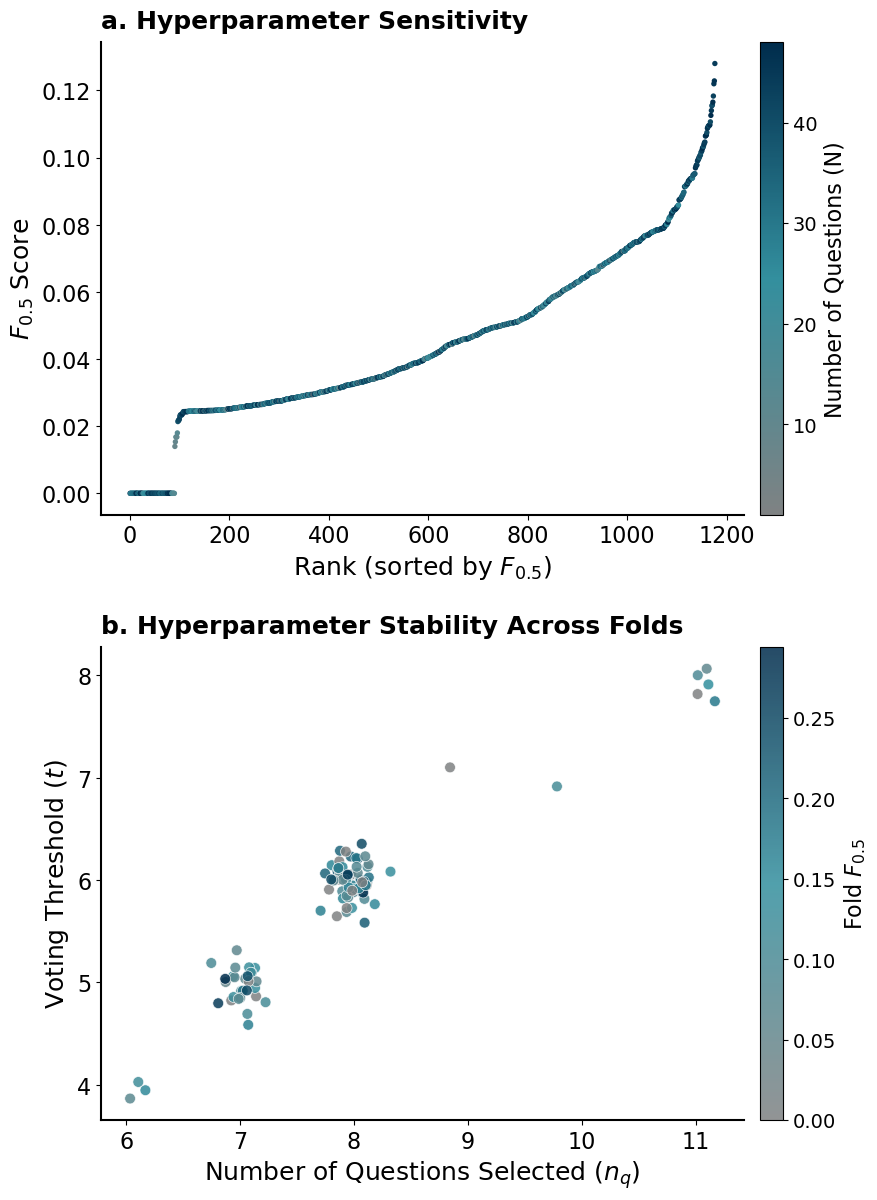

In [88]:
# === Combined Figure: Rank-F0.5 Convergence (a) + Stability Scatter (b) ===
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# --- Custom colormap matching notebook palette ---
cmap = mcolors.LinearSegmentedColormap.from_list(
    "rrf_cmap", ["#7f8283", "#338f9e", "#002c4c"]
)

# =====================================================================
# Data for panel (a): Rank vs F0.5
# =====================================================================
gs_path = Path("../precomputed/gpt_4o_mini/grid_search_results_anonymised.csv")
gs_df = pd.read_csv(gs_path)

heatmap_data = gs_df.pivot(index='Score_Threshold', columns='Num_Questions', values='F0.5')

valid_entries = []
for i, score_threshold in enumerate(heatmap_data.index):
    for j, num_questions in enumerate(heatmap_data.columns):
        if score_threshold <= num_questions:
            value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                valid_entries.append({
                    'Score_Threshold': score_threshold,
                    'Num_Questions': num_questions,
                    'F0.5': value
                })

valid_df = pd.DataFrame(valid_entries)
valid_df = valid_df.sort_values(by='F0.5').reset_index(drop=True)
valid_df['Rank'] = valid_df.index + 1

norm_a = plt.Normalize(valid_df['Num_Questions'].min(), valid_df['Num_Questions'].max())

# =====================================================================
# Data for panel (b): Stability scatter
# =====================================================================
file_primary = results_dir / "nested_cv_llm__anonymisedsimilarity_hamming_0_15_optimiseF0_5_sortbyf0_5.csv"
df_stab = pd.read_csv(file_primary)

jitter_x = df_stab['Best_n_q'] + np.random.default_rng(42).normal(0, 0.15, size=len(df_stab))
jitter_y = df_stab['Best_Thr'] + np.random.default_rng(43).normal(0, 0.15, size=len(df_stab))

# =====================================================================
# Combined figure
# =====================================================================
fig = plt.figure(figsize=(10, 14))
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.28)

# --- Panel (a): Rank vs F0.5 ---
ax_a = fig.add_subplot(gs[0])

ax_a.scatter(valid_df['Rank'], valid_df['F0.5'],
             c=cmap(norm_a(valid_df['Num_Questions'])),
             edgecolor='none', s=15)

ax_a.set_xlabel('Rank (sorted by $F_{0.5}$)', fontsize=18)
ax_a.set_ylabel('$F_{0.5}$ Score', fontsize=18)
ax_a.set_title('a. Hyperparameter Sensitivity', loc='left', fontweight='bold', fontsize=18, pad=10)
ax_a.tick_params(labelsize=16)

for spine in ['top', 'right']:
    ax_a.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax_a.spines[spine].set_visible(True)
    ax_a.spines[spine].set_color('black')
    ax_a.spines[spine].set_linewidth(1.5)
ax_a.grid(False)

sm_a = plt.cm.ScalarMappable(cmap=cmap, norm=norm_a)
sm_a.set_array([])
cbar_a = plt.colorbar(sm_a, ax=ax_a, pad=0.02)
cbar_a.set_label('Number of Questions (N)', fontsize=16)
cbar_a.ax.tick_params(labelsize=14)

# --- Panel (b): Stability scatter ---
ax_b = fig.add_subplot(gs[1])

scatter_b = ax_b.scatter(
    jitter_x, jitter_y,
    c=df_stab['F05_Outer'],
    cmap=cmap,
    s=60,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85,
    vmin=0, vmax=df_stab['F05_Outer'].max()
)

ax_b.set_xlabel('Number of Questions Selected ($n_q$)', fontsize=18)
ax_b.set_ylabel('Voting Threshold ($t$)', fontsize=18)
ax_b.set_title('b. Hyperparameter Stability Across Folds', loc='left', fontweight='bold', fontsize=18, pad=10)
ax_b.tick_params(axis='both', labelsize=16)

for spine in ['top', 'right']:
    ax_b.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax_b.spines[spine].set_visible(True)
    ax_b.spines[spine].set_color('black')
    ax_b.spines[spine].set_linewidth(1.5)
ax_b.grid(False)

cbar_b = plt.colorbar(scatter_b, ax=ax_b, pad=0.02)
cbar_b.set_label('Fold $F_{0.5}$', fontsize=16)
cbar_b.ax.tick_params(labelsize=14)
plt.show()

## Clinical Trials: TOP Phase I Results

RRF applied to clinical trial outcome prediction (TOP dataset, Phase I).
Comparison with elastic net baseline and published methods from the literature.

In [82]:
# === TOP Phase I: Clinical Trial Results Table ===
# F0.5-optimized (consistent with founder task), 10 repeats

ct_base = Path("../clinical_trials/results/phase_I")

# --- RRF ---
rrf_ct = pd.read_csv(ct_base / "primary_results/primary_model_repeat_metrics.csv")

# --- Elastic Net ---
lr_ct = pd.read_csv(ct_base / "logreg_results/logreg_repeat_metrics.csv")

# --- Published baselines (Fu et al., HINT) ---
published_baselines = {
    "LR":         {"PR_AUC": (0.500, 0.005), "ROC_AUC": (0.520, 0.006), "F1": (0.604, 0.005)},
    "RF":         {"PR_AUC": (0.518, 0.005), "ROC_AUC": (0.525, 0.006), "F1": (0.621, 0.005)},
    "AdaBoost":   {"PR_AUC": (0.519, 0.005), "ROC_AUC": (0.526, 0.006), "F1": (0.622, 0.007)},
    "kNN+RF":     {"PR_AUC": (0.531, 0.006), "ROC_AUC": (0.538, 0.005), "F1": (0.625, 0.007)},
    "FFNN":       {"PR_AUC": (0.547, 0.010), "ROC_AUC": (0.550, 0.010), "F1": (0.634, 0.015)},
    "DeepEnroll": {"PR_AUC": (0.568, 0.007), "ROC_AUC": (0.575, 0.013), "F1": (0.648, 0.011)},
    "COMPOSE":    {"PR_AUC": (0.564, 0.007), "ROC_AUC": (0.571, 0.011), "F1": (0.658, 0.009)},
    "HINT":       {"PR_AUC": (0.567, 0.010), "ROC_AUC": (0.576, 0.008), "F1": (0.665, 0.010)},
}

# --- Build table ---
rows = []
for label, df in [("RRF", rrf_ct), ("Elastic net", lr_ct)]:
    rows.append({
        "Method": label,
        "PR-AUC": f"{df['PR_AUC'].mean():.3f} $\\pm$ {df['PR_AUC'].std(ddof=1):.3f}",
        "ROC-AUC": f"{df['ROC_AUC'].mean():.3f} $\\pm$ {df['ROC_AUC'].std(ddof=1):.3f}",
        "F1": f"{df['F1'].mean():.3f} $\\pm$ {df['F1'].std(ddof=1):.3f}",
    })

for name, metrics in published_baselines.items():
    rows.append({
        "Method": name,
        "PR-AUC": f"{metrics['PR_AUC'][0]:.3f} $\\pm$ {metrics['PR_AUC'][1]:.3f}",
        "ROC-AUC": f"{metrics['ROC_AUC'][0]:.3f} $\\pm$ {metrics['ROC_AUC'][1]:.3f}",
        "F1": f"{metrics['F1'][0]:.3f} $\\pm$ {metrics['F1'][1]:.3f}",
    })

table_df = pd.DataFrame(rows)
print("📊 TOP Phase I — Main Comparison Table\n")
print(table_df.to_markdown(index=False))

# --- Operating-point diagnostics ---
print("\n\n📊 Operating-Point Diagnostics\n")
diag_rows = []
for label, df in [("RRF", rrf_ct), ("Elastic net", lr_ct)]:
    d = {}
    for col in ["PR_AUC", "ROC_AUC", "F1", "Precision", "Recall", "Specificity", "Pred_Pos_Rate"]:
        d[col] = f"{df[col].mean():.3f} ± {df[col].std(ddof=1):.3f}"
    d["Method"] = label
    diag_rows.append(d)
diag_df = pd.DataFrame(diag_rows).set_index("Method")
print(diag_df.T.to_markdown())

# --- Hyperparameter stability ---
print("\n\n📊 RRF Hyperparameter Selection (10 repeats)")
from collections import Counter
configs = Counter(zip(rrf_ct['n_q'].astype(int), rrf_ct['thr'].astype(int)))
for (nq, thr), count in configs.most_common():
    print(f"  n_q={nq}, thr={thr}: {count}/10 repeats")

📊 TOP Phase I — Main Comparison Table

| Method      | PR-AUC            | ROC-AUC           | F1                |
|:------------|:------------------|:------------------|:------------------|
| RRF         | 0.638 $\pm$ 0.005 | 0.596 $\pm$ 0.003 | 0.655 $\pm$ 0.019 |
| Elastic net | 0.632 $\pm$ 0.002 | 0.594 $\pm$ 0.004 | 0.641 $\pm$ 0.006 |
| LR          | 0.500 $\pm$ 0.005 | 0.520 $\pm$ 0.006 | 0.604 $\pm$ 0.005 |
| RF          | 0.518 $\pm$ 0.005 | 0.525 $\pm$ 0.006 | 0.621 $\pm$ 0.005 |
| AdaBoost    | 0.519 $\pm$ 0.005 | 0.526 $\pm$ 0.006 | 0.622 $\pm$ 0.007 |
| kNN+RF      | 0.531 $\pm$ 0.006 | 0.538 $\pm$ 0.005 | 0.625 $\pm$ 0.007 |
| FFNN        | 0.547 $\pm$ 0.010 | 0.550 $\pm$ 0.010 | 0.634 $\pm$ 0.015 |
| DeepEnroll  | 0.568 $\pm$ 0.007 | 0.575 $\pm$ 0.013 | 0.648 $\pm$ 0.011 |
| COMPOSE     | 0.564 $\pm$ 0.007 | 0.571 $\pm$ 0.011 | 0.658 $\pm$ 0.009 |
| HINT        | 0.567 $\pm$ 0.010 | 0.576 $\pm$ 0.008 | 0.665 $\pm$ 0.010 |


📊 Operating-Point Diagnostics

|               

## Clinical Trials: Operating-Point Diagnostics (Appendix)

Detailed operating-point metrics and hyperparameter stability analysis.

In [83]:
# === TOP Phase I: Operating-Point Diagnostics Table (Appendix) ===

ct_base = Path("../clinical_trials/results/phase_I")
rrf_ct = pd.read_csv(ct_base / "primary_results/primary_model_repeat_metrics.csv")
lr_ct = pd.read_csv(ct_base / "logreg_results/logreg_repeat_metrics.csv")

metrics_of_interest = ["PR_AUC", "ROC_AUC", "F1", "Precision", "Recall", "Specificity", "Pred_Pos_Rate"]
display_names = {
    "PR_AUC": "PR-AUC", "ROC_AUC": "ROC-AUC", "F1": "F1",
    "Precision": "Precision", "Recall": "Recall",
    "Specificity": "Specificity", "Pred_Pos_Rate": "Pred. Pos. Rate",
}

rows = []
for col in metrics_of_interest:
    rrf_mean, rrf_sd = rrf_ct[col].mean(), rrf_ct[col].std(ddof=1)
    lr_mean, lr_sd = lr_ct[col].mean(), lr_ct[col].std(ddof=1)
    rows.append({
        "Metric": display_names[col],
        "RRF": f"{rrf_mean:.3f} ± {rrf_sd:.3f}",
        "Elastic net": f"{lr_mean:.3f} ± {lr_sd:.3f}",
    })

diag_df = pd.DataFrame(rows)
print("📊 Appendix Table: Operating-Point Diagnostics (mean ± SD, 10 repeats)\n")
print(diag_df.to_markdown(index=False))

# LaTeX version
print("\n\n--- LaTeX ---")
print(r"\begin{tabular}{lcc}")
print(r"\toprule")
print(r"Metric & RRF & Elastic net \\")
print(r"\midrule")
for _, r in diag_df.iterrows():
    rrf_val = r["RRF"].replace("±", "$\\pm$")
    lr_val = r["Elastic net"].replace("±", "$\\pm$")
    print(f"{r['Metric']} & {rrf_val} & {lr_val} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")

# Hyperparameter stability summary
print("\n\n📊 RRF Hyperparameter Selection Across 10 Repeats")
from collections import Counter
configs = Counter(zip(rrf_ct["n_q"].astype(int), rrf_ct["thr"].astype(int)))
for (nq, thr), count in configs.most_common():
    print(f"  n_q={nq}, thr={thr}: {count}/10 repeats")


📊 Appendix Table: Operating-Point Diagnostics (mean ± SD, 10 repeats)

| Metric          | RRF           | Elastic net   |
|:----------------|:--------------|:--------------|
| PR-AUC          | 0.638 ± 0.005 | 0.632 ± 0.002 |
| ROC-AUC         | 0.596 ± 0.003 | 0.594 ± 0.004 |
| F1              | 0.655 ± 0.019 | 0.641 ± 0.006 |
| Precision       | 0.572 ± 0.002 | 0.581 ± 0.005 |
| Recall          | 0.767 ± 0.054 | 0.716 ± 0.020 |
| Specificity     | 0.289 ± 0.055 | 0.360 ± 0.031 |
| Pred. Pos. Rate | 0.742 ± 0.055 | 0.682 ± 0.025 |


--- LaTeX ---
\begin{tabular}{lcc}
\toprule
Metric & RRF & Elastic net \\
\midrule
PR-AUC & 0.638 $\pm$ 0.005 & 0.632 $\pm$ 0.002 \\
ROC-AUC & 0.596 $\pm$ 0.003 & 0.594 $\pm$ 0.004 \\
F1 & 0.655 $\pm$ 0.019 & 0.641 $\pm$ 0.006 \\
Precision & 0.572 $\pm$ 0.002 & 0.581 $\pm$ 0.005 \\
Recall & 0.767 $\pm$ 0.054 & 0.716 $\pm$ 0.020 \\
Specificity & 0.289 $\pm$ 0.055 & 0.360 $\pm$ 0.031 \\
Pred. Pos. Rate & 0.742 $\pm$ 0.055 & 0.682 $\pm$ 0.025 \\
\bottomrule


## Clinical Trials: Recall-Specificity Pareto (Appendix)

Pareto frontier showing the recall-specificity trade-off across beta values.

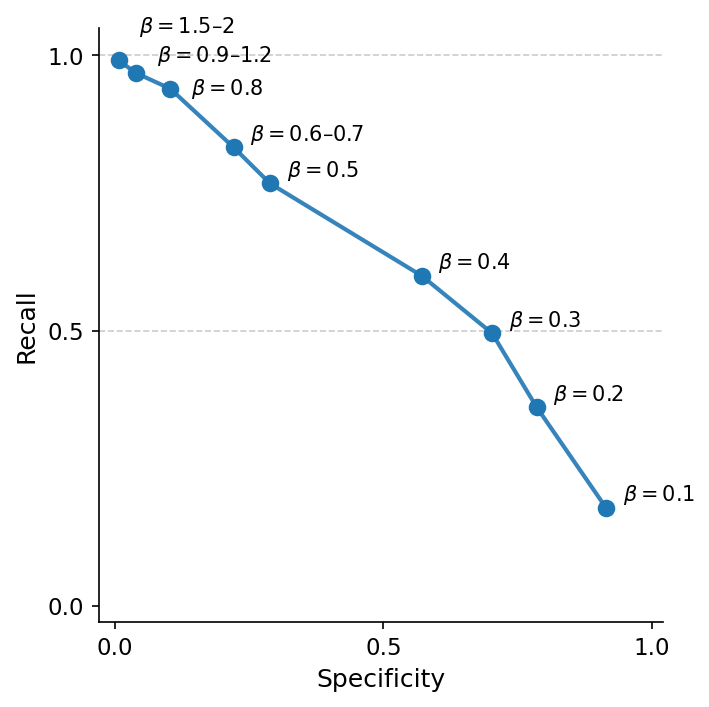

In [84]:
# === TOP Phase I: Recall–Specificity Pareto Figure (Appendix) ===

import matplotlib.ticker as mticker

ct_base = Path("../clinical_trials/results/phase_I")
beta_df = pd.read_csv(ct_base / "ablation_results/beta_sweep_summary.csv")

# --- Collapse identical operating points ---
tmp = beta_df.copy()
tmp["spec_r"] = np.round(tmp["specificity_mean"].astype(float), 6)
tmp["rec_r"] = np.round(tmp["recall_mean"].astype(float), 6)

g = (
    tmp.groupby(["spec_r", "rec_r"])
    .agg(betas=("beta", lambda x: sorted(x.tolist())))
    .reset_index()
)

def beta_label(betas):
    if len(betas) == 1:
        return rf"$\beta = {betas[0]:g}$"
    return rf"$\beta = {betas[0]:g}$–${betas[-1]:g}$"

g["label"] = g["betas"].apply(beta_label)
g["beta_med"] = g["betas"].apply(lambda x: np.median(x))
g = g.sort_values("beta_med").reset_index(drop=True)

# --- Colours ---
DARK_NAVY = "#002c4c"
TEAL = "#338f9e"

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

spec = g["spec_r"].to_numpy()
rec = g["rec_r"].to_numpy()

ax.plot(spec, rec, linewidth=2, alpha=0.9, zorder=2)
ax.scatter(spec, rec, s=55,  zorder=3)

# --- Dashed reference lines ---
for y in [0.5, 1.0]:
    ax.axhline(y, color="#cccccc", linewidth=0.8, linestyle="--", zorder=1)

ax.set_xlim(-0.03, 1.02)
ax.set_ylim(-0.03, 1.05)
ax.set_xticks([0.0, 0.5, 1.0])
ax.set_yticks([0.0, 0.5, 1.0])
ax.set_xlabel("Specificity", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.tick_params(labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Label placement ---
# Top-left cluster needs careful offsets to avoid overlap
tl = g[(g["spec_r"] < 0.12) & (g["rec_r"] > 0.90)].copy().sort_values("rec_r", ascending=False)
tl_offsets = [(10, 16), (10, 8), (10, 0)]
offset_lookup = {}
for (_, row), off in zip(tl.iterrows(), tl_offsets):
    offset_lookup[(float(row["spec_r"]), float(row["rec_r"]))] = off

base_offset = (8, 6)
for _, row in g.iterrows():
    x, y = float(row["spec_r"]), float(row["rec_r"])
    off = offset_lookup.get((x, y), base_offset)
    ax.annotate(
        row["label"], xy=(x, y), xytext=off,
        textcoords="offset points", ha="left", va="center", fontsize=10,
    )

plt.tight_layout()
plt.show()
